In [12]:
import torch
import torchvision
import matplotlib.pyplot as plt
import random


from torch import nn
from torchvision import transforms
from torchinfo import summary
from going_modular import data_setup, engine, predictions, utils
from helper_functions import download_data, set_seeds, plot_loss_curves
from pathlib import Path

device = "cuda" if torch.cuda.is_available() else "cpu"
device

c:\Users\abhit\OneDrive\Documents\Programming\neuron\GOD-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'cuda'

In [ ]:
# split data folder fir 20%
train_dir = data_20_percent_path / "train"
test_dir = data_20_percent_path / "test"

In [15]:
effnetb2_weights = torchvision.models.EfficientNet_B2_Weights.DEFAULT

effnetb2_transforms = effnetb2_weights.transforms()

effnetb2 = torchvision.models.efficientnet_b2(weights = effnetb2_weights)

for param in effnetb2.parameters():
    param.requires_grad = False

effnetb2.classifier

Sequential(
  (0): Dropout(p=0.3, inplace=True)
  (1): Linear(in_features=1408, out_features=1000, bias=True)
)

In [16]:
effnetb2.classifier = nn.Sequential(
    nn.Dropout(p = 0.3, inplace = True),
    nn.Linear(
        in_features = 1408,
        out_features = 3
    )
)

In [17]:
def create_effnetb2(num_classes: int = 3, seed: int = 42):
    weights = torchvision.models.EfficientNet_B2_Weights.DEFAULT

    transforms = effnetb2_weights.transforms()

    effnetb2 = torchvision.models.efficientnet_b2(weights = effnetb2_weights)

    for param in effnetb2.parameters():
        param.requires_grad = False

    torch.manual_seed(seed)    

    effnetb2.classifier = nn.Sequential(
        nn.Dropout(p = 0.3, inplace = True),
        nn.Linear(
            in_features = 1408,
            out_features = 3
        )
    )

    return effnetb2, transforms 

In [18]:
effnetb2, effnetb2_transforms = create_effnetb2(
    num_classes = 3,
    seed = 42
)

In [19]:
from torchinfo import summary


summary(effnetb2, 
         input_size=(1, 3, 224, 224),
         col_names=["input_size", "output_size", "num_params", "trainable"],
         col_width=20,
         row_settings=["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [1, 3, 224, 224]     [1, 3]               --                   Partial
├─Sequential (features)                                      [1, 3, 224, 224]     [1, 1408, 7, 7]      --                   False
│    └─Conv2dNormActivation (0)                              [1, 3, 224, 224]     [1, 32, 112, 112]    --                   False
│    │    └─Conv2d (0)                                       [1, 3, 224, 224]     [1, 32, 112, 112]    (864)                False
│    │    └─BatchNorm2d (1)                                  [1, 32, 112, 112]    [1, 32, 112, 112]    (64)                 False
│    │    └─SiLU (2)                                         [1, 32, 112, 112]    [1, 32, 112, 112]    --                   --
│    └─Sequential (1)                                        [1, 32, 112, 112]    [1, 1

In [20]:
train_dataloader, test_dataloader, class_names = data_setup.create_dataloader(
    train_dir = train_dir,
    test_dir = test_dir,
    transform = effnetb2_transforms,
    batch_size = 32
)

In [21]:
optimizer = torch.optim.Adam(params = effnetb2.parameters(), lr = 1e-3)

loss_fn = nn.CrossEntropyLoss()

set_seeds()

effnetb2_results = engine.train(
    model = effnetb2,
    train_dataloader = train_dataloader,
    test_dataloader = test_dataloader,
    loss_fn = loss_fn,
    optimizer = optimizer,
    epochs = 10,
    device = device,
    writer = None
)

 10%|█         | 1/10 [00:25<03:53, 25.92s/it]

Epoch : 1 |train loss : 0.9911 |train acc : 0.5646 |test loss : 0.7399 |test acc : 0.9284


 20%|██        | 2/10 [00:51<03:27, 25.94s/it]

Epoch : 2 |train loss : 0.7159 |train acc : 0.8458 |test loss : 0.5882 |test acc : 0.9472


 30%|███       | 3/10 [01:14<02:49, 24.27s/it]

...

Epoch : 8 |train loss : 0.3972 |train acc : 0.9000 |test loss : 0.3451 |test acc : 0.9443


 90%|█████████ | 9/10 [03:26<00:22, 22.20s/it]

Epoch : 9 |train loss : 0.3774 |train acc : 0.8854 |test loss : 0.3124 |test acc : 0.9193


100%|██████████| 10/10 [03:48<00:00, 22.87s/it]

Epoch : 10 |train loss : 0.3712 |train acc : 0.8583 |test loss : 0.2796 |test acc : 0.9688


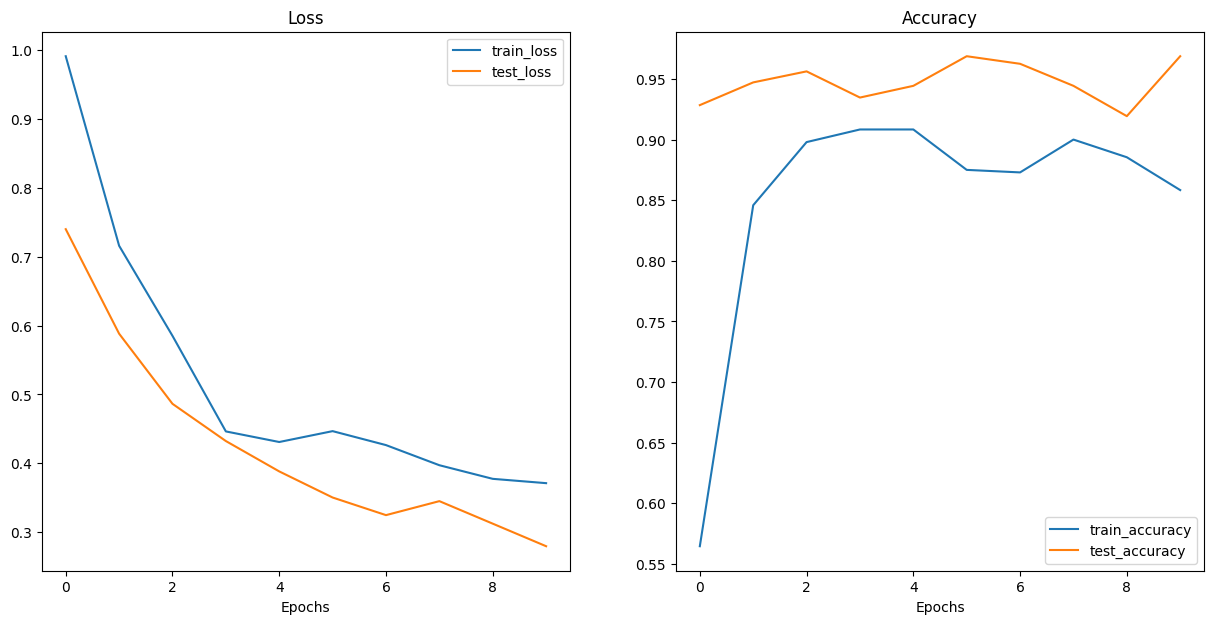

In [22]:
plot_loss_curves(effnetb2_results)

In [23]:
utils.save_model(
    model = effnetb2,
    target_dir = "models",
    model_name = "model_deployment_effnet.pth"
)

[INFO] saving model to models\model_deployment_effnet.pth


In [24]:
effnetb2_size = Path("models/model_deployment_effnet.pth").stat().st_size // (1024*1024)
print(f"Pretrained EffNetB2 feature extractor model size: {effnetb2_size} MB")

Pretrained EffNetB2 feature extractor model size: 29 MB


In [25]:
effnetb2_param_size = sum(torch.numel(param) for param in effnetb2.parameters())
effnetb2_param_size

7705221

In [26]:
effnetb2_stats = {
    "test_loss" : effnetb2_results["test_loss"][-1],
    "test_acc" : effnetb2_results["test_acc"][-1],
    "number of params" : effnetb2_param_size,
    "model size" : effnetb2_size
}

effnetb2_stats

{'test_loss': 0.2795968472957611,
 'test_acc': 0.96875,
 'number of params': 7705221,
 'model size': 29}

In [27]:
def create_vit(num_classes: int = 3, seed: int = 42):

    weights = torchvision.models.ViT_B_16_Weights.DEFAULT
    transforms = weights.transforms()
    model = torchvision.models.vit_b_16(weights = weights)

    for param in model.parameters():
        param.requires_grad = False

    torch.manual_seed(seed)
    model.heads = nn.Sequential(
        nn.Linear(
            in_features = 768,
            out_features = num_classes
        )
    )

    return model, transforms

In [28]:
vit, vit_transforms = create_vit(
    num_classes = 3,
    seed = 42
)

In [29]:
from torchinfo import summary

summary(vit, 
         input_size=(1, 3, 224, 224),
         col_names=["input_size", "output_size", "num_params", "trainable"],
         col_width=20,
         row_settings=["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
VisionTransformer (VisionTransformer)                        [1, 3, 224, 224]     [1, 3]               768                  Partial
├─Conv2d (conv_proj)                                         [1, 3, 224, 224]     [1, 768, 14, 14]     (590,592)            False
├─Encoder (encoder)                                          [1, 197, 768]        [1, 197, 768]        151,296              False
│    └─Dropout (dropout)                                     [1, 197, 768]        [1, 197, 768]        --                   --
│    └─Sequential (layers)                                   [1, 197, 768]        [1, 197, 768]        --                   False
│    │    └─EncoderBlock (encoder_layer_0)                   [1, 197, 768]        [1, 197, 768]        (7,087,872)          False
│    │    └─EncoderBlock (encoder_layer_1)                   [1, 197, 768]        [1, 1

In [30]:
train_dataloader_vit, test_dataloader_vit, class_names = data_setup.create_dataloader(
    train_dir = train_dir,
    test_dir = test_dir,
    transform = vit_transforms,
    batch_size = 32
)

In [31]:
optimizer = torch.optim.Adam(params = vit.parameters(), lr = 1e-3)

loss_fn = nn.CrossEntropyLoss()

set_seeds()

vit_results = engine.train(
    model = vit,
    train_dataloader = train_dataloader_vit,
    test_dataloader = test_dataloader_vit,
    epochs = 10,
    optimizer = optimizer,
    loss_fn = loss_fn,
    device = device,
    writer = None
)

 10%|█         | 1/10 [00:37<05:33, 37.02s/it]

Epoch : 1 |train loss : 0.7020 |train acc : 0.7521 |test loss : 0.2714 |test acc : 0.9381


 20%|██        | 2/10 [01:13<04:51, 36.43s/it]

Epoch : 2 |train loss : 0.2532 |train acc : 0.9062 |test loss : 0.1672 |test acc : 0.9602


 30%|███       | 3/10 [01:49<04:14, 36.41s/it]

...

Epoch : 8 |train loss : 0.0919 |train acc : 0.9812 |test loss : 0.0764 |test acc : 0.9722


 90%|█████████ | 9/10 [05:33<00:36, 36.81s/it]

Epoch : 9 |train loss : 0.0922 |train acc : 0.9792 |test loss : 0.0734 |test acc : 0.9784


100%|██████████| 10/10 [06:09<00:00, 36.98s/it]

Epoch : 10 |train loss : 0.0658 |train acc : 0.9833 |test loss : 0.0644 |test acc : 0.9847


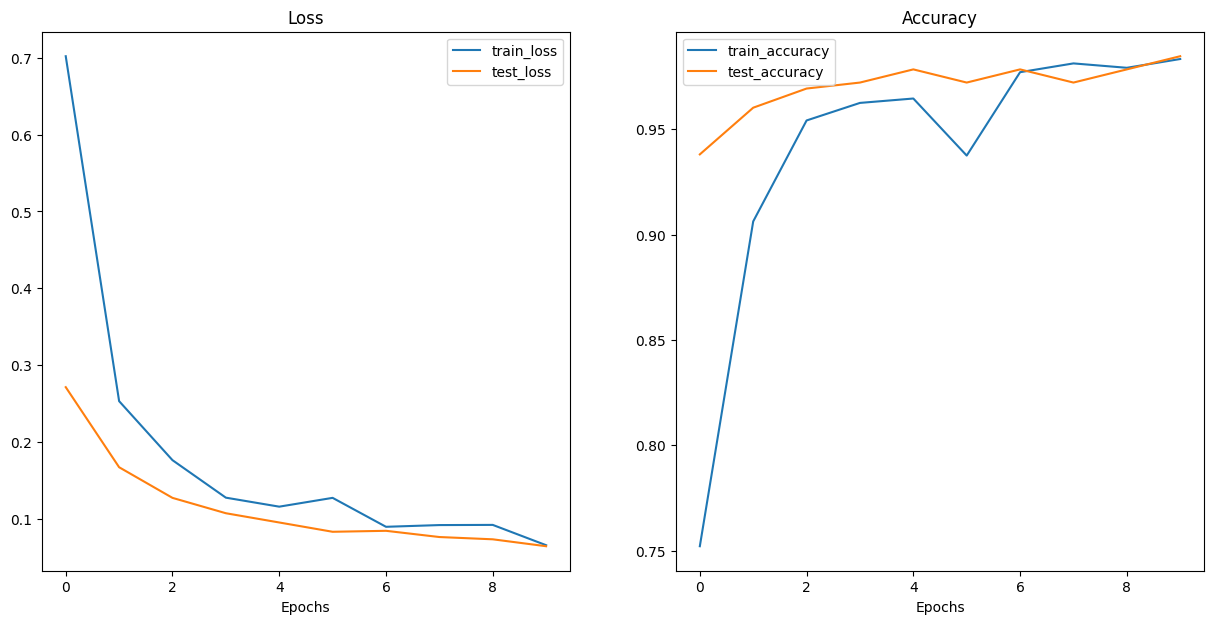

In [32]:
plot_loss_curves(vit_results)

In [33]:
utils.save_model(
    model = vit,
    target_dir = "models",
    model_name = "model_deployment_vit.pth"
)

[INFO] saving model to models\model_deployment_vit.pth


In [34]:
vit_size = Path("models/model_deployment_vit.pth").stat().st_size // (1024*1024)
print(f"Pretrained ViT feature extractor model size: {vit_size} MB")

Pretrained ViT feature extractor model size: 327 MB


In [35]:
vit_param_size = sum(torch.numel(param) for param in vit.parameters())
vit_param_size

85800963

In [36]:
vit_stats = {
    "test_loss" : vit_results["test_loss"][-1],
    "test_acc" : vit_results["test_acc"][-1],
    "number of params" : vit_param_size,
    "model size" : vit_size
}

vit_stats

{'test_loss': 0.0644345322623849,
 'test_acc': 0.984659090909091,
 'number of params': 85800963,
 'model size': 327}

In [37]:
print(f"[INFO] Finding all filepaths ending with '.jpg' in directory: {test_dir}")
test_data_paths = list(Path(test_dir).glob("*/*.jpg"))
test_data_paths[:5]

[INFO] Finding all filepaths ending with '.jpg' in directory: data\pizza_steak_sushi_20_percent\test


[WindowsPath('data/pizza_steak_sushi_20_percent/test/pizza/1001116.jpg'),
 WindowsPath('data/pizza_steak_sushi_20_percent/test/pizza/1032754.jpg'),
 WindowsPath('data/pizza_steak_sushi_20_percent/test/pizza/1067986.jpg'),
 WindowsPath('data/pizza_steak_sushi_20_percent/test/pizza/129666.jpg'),
 WindowsPath('data/pizza_steak_sushi_20_percent/test/pizza/1315645.jpg')]

In [38]:
import pathlib

from PIL import Image
from timeit import default_timer as timer
from typing import List, Dict
from tqdm.auto import tqdm

def pred_and_store(paths: List[pathlib.Path], model: torch.nn.Module, transform: torchvision.transforms, class_names: List[str], device: str = "cuda" if torch.cuda.is_available() else "cpu") -> List[Dict]:

    pred_list = []

    for path in tqdm(paths):

        pred_dict = {}

        pred_dict["image_path"] = path
        class_name = path.parent.stem
        pred_dict["class_name"] = class_name

        start_time = timer()

        img = Image.open(path)

        transformed_img = transform(img).unsqueeze(dim = 0).to(device)

        model.to(device)
        model.eval()

        with torch.inference_mode():

            pred_logit = model(transformed_img)
            pred_prob = torch.softmax(pred_logit, dim = 1)
            pred_label = torch.argmax(pred_prob, dim = 1)
            pred_class = class_names[pred_label.cpu()]

            pred_dict["pred_prob"] = round(pred_prob.unsqueeze(dim=0).max().cpu().item(), 4)
            pred_dict["pred_class"] = pred_class

            end_time = timer()

            pred_dict["time_for_pred"] = round(end_time - start_time, 4)

        pred_dict["correct"] = class_name == pred_class

        pred_list.append(pred_dict)

    return pred_list


In [39]:
effnetb2_test_pred_dicts = pred_and_store(
    paths = test_data_paths,
    model = effnetb2,
    transform = effnetb2_transforms,
    class_names = class_names,
    device = "cpu"
)

100%|██████████| 150/150 [00:11<00:00, 12.79it/s]


In [40]:
effnetb2_test_pred_dicts[:2]

[{'image_path': WindowsPath('data/pizza_steak_sushi_20_percent/test/pizza/1001116.jpg'),
  'class_name': 'pizza',
  'pred_prob': 0.994,
  'pred_class': 'pizza',
  'time_for_pred': 0.1464,
  'correct': True},
 {'image_path': WindowsPath('data/pizza_steak_sushi_20_percent/test/pizza/1032754.jpg'),
  'class_name': 'pizza',
  'pred_prob': 0.4643,
  'pred_class': 'pizza',
  'time_for_pred': 0.0937,
  'correct': True}]

In [41]:
import pandas as pd
effnetb2_test_pred_df = pd.DataFrame(effnetb2_test_pred_dicts)
effnetb2_test_pred_df.head()
effnetb2_test_pred_df.correct.value_counts()
effnetb2_average_time_per_pred = round(effnetb2_test_pred_df.time_for_pred.mean(), 4)
print(f"EffNetB2 average time per prediction: {effnetb2_average_time_per_pred} seconds")

EffNetB2 average time per prediction: 0.0776 seconds


In [42]:
effnetb2_stats["time_per_pred_cpu"] = effnetb2_average_time_per_pred
effnetb2_stats

{'test_loss': 0.2795968472957611,
 'test_acc': 0.96875,
 'number of params': 7705221,
 'model size': 29,
 'time_per_pred_cpu': np.float64(0.0776)}

In [43]:
vit_test_pred_dicts = pred_and_store(
    paths = test_data_paths,
    model = vit,
    transform = vit_transforms,
    class_names = class_names,
    device = "cpu"
)

100%|██████████| 150/150 [00:42<00:00,  3.51it/s]


In [44]:
vit_test_pred_dicts[:2]

[{'image_path': WindowsPath('data/pizza_steak_sushi_20_percent/test/pizza/1001116.jpg'),
  'class_name': 'pizza',
  'pred_prob': 0.9987,
  'pred_class': 'pizza',
  'time_for_pred': 0.5681,
  'correct': True},
 {'image_path': WindowsPath('data/pizza_steak_sushi_20_percent/test/pizza/1032754.jpg'),
  'class_name': 'pizza',
  'pred_prob': 0.9957,
  'pred_class': 'pizza',
  'time_for_pred': 0.2787,
  'correct': True}]

In [45]:
vit_test_pred_df = pd.DataFrame(vit_test_pred_dicts)
vit_test_pred_df.head()
vit_test_pred_df.correct.value_counts()
vit_average_time_per_pred = round(vit_test_pred_df.time_for_pred.mean(), 4)
print(f"EffNetB2 average time per prediction: {vit_average_time_per_pred} seconds")

EffNetB2 average time per prediction: 0.2834 seconds


In [46]:
vit_stats["time_per_pred_cpu"] = vit_average_time_per_pred
vit_stats

{'test_loss': 0.0644345322623849,
 'test_acc': 0.984659090909091,
 'number of params': 85800963,
 'model size': 327,
 'time_per_pred_cpu': np.float64(0.2834)}

In [47]:
df = pd.DataFrame([effnetb2_stats, vit_stats])

df["model"] = ["EffNetB2", "ViT"]

df["test_acc"] = round(df["test_acc"]*100, 2)

df

,test_loss,test_acc,number of params,model size,time_per_pred_cpu,model
0,0.279597,96.88,7705221,29,0.0776,EffNetB2
1,0.064435,98.47,85800963,327,0.2834,ViT


In [48]:
pd.DataFrame(data = (df.set_index("model").loc["ViT"] / df.set_index("model").loc["EffNetB2"]), columns = ["ViT to EffNetB2 ratios"]).T

,test_loss,test_acc,number of params,model size,time_per_pred_cpu
ViT to EffNetB2 ratios,0.230455,1.016412,11.135432,11.275862,3.652062


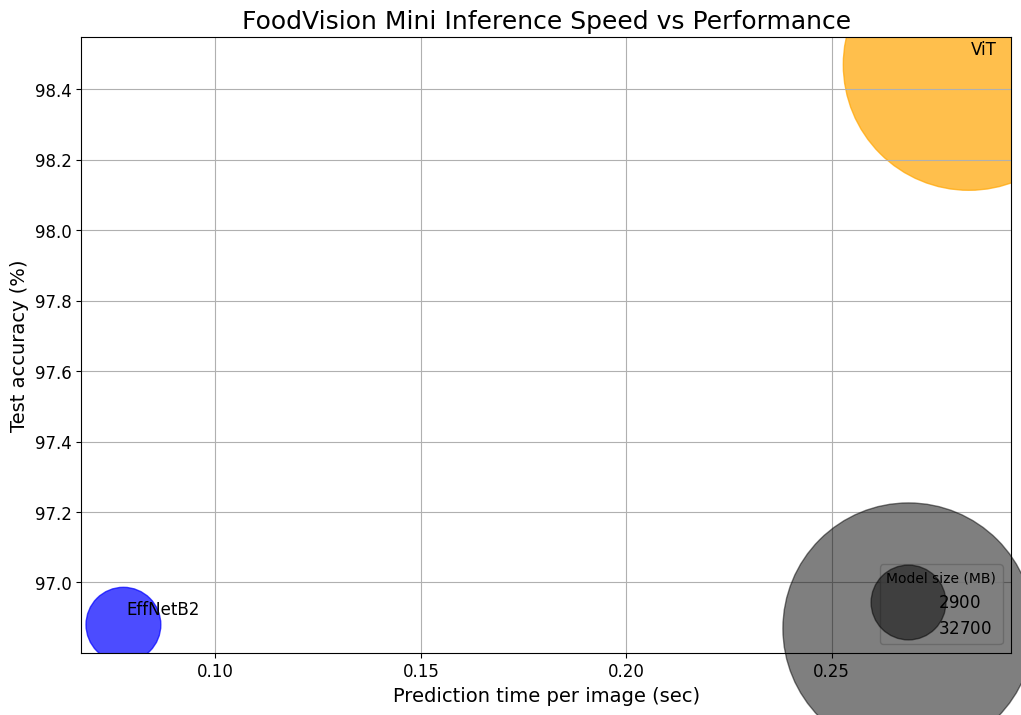

In [49]:
fig, ax = plt.subplots(figsize = (12, 8))

scatter = ax.scatter(x = df["time_per_pred_cpu"], y = df["test_acc"], c = ["blue", "orange"], s = df["model size"]*100, alpha = 0.7)

ax.set_title("FoodVision Mini Inference Speed vs Performance", fontsize = 18)
ax.set_xlabel("Prediction time per image (sec)", fontsize = 14)
ax.set_ylabel("Test accuracy (%)", fontsize = 14)
ax.tick_params(axis = 'both', labelsize = 12)
ax.grid(True)

for index, row in df.iterrows():
    ax.annotate(text = row["model"], xy = (row["time_per_pred_cpu"]+0.0006, row["test_acc"]+0.03), size = 12)

handles, labels = scatter.legend_elements(prop = "sizes", alpha = 0.5)
model_size_legend = ax.legend(handles, labels, loc = "lower right", title = "Model size (MB)", fontsize = 12)

plt.savefig("images/09-foodvision-mini-inference-speed-vs-performance.jpg")

plt.show()

In [50]:
import gradio as gr

from typing import Tuple

effnetb2.to("cpu")
next(iter(effnetb2.parameters())).device

def predict(img) -> Tuple[Dict, float]:

    start = timer()

    img = effnetb2_transforms(img).unsqueeze(dim = 0)

    effnetb2.eval()

    with torch.inference_mode():

        pred_probs = torch.softmax(effnetb2(img), dim = 1)

    pred_labels_and_prob = {class_names[i]: float(pred_probs[0][i]) for i in range(len(class_names))}
    pred_time = round(timer() - start, 5)


    return pred_labels_and_prob, pred_time

In [51]:
import random 

test_data_paths = list(Path(test_dir).glob("*/*.jpg"))

random_img = random.sample(test_data_paths, k = 1)[0]

image = Image.open(random_img)

print(f"[INFO] Predicting on image at path: {random_img}\n")

pred_dict, pred_time = predict(img=image)
print(f"Prediction label and probability dictionary: \n{pred_dict}")
print(f"Prediction time: {pred_time} seconds")

[INFO] Predicting on image at path: data\pizza_steak_sushi_20_percent\test\steak\831681.jpg

Prediction label and probability dictionary: 
{'pizza': 0.04271165654063225, 'steak': 0.9234054088592529, 'sushi': 0.0338829904794693}
Prediction time: 0.08265 seconds


In [52]:
example_list = [[str(filepath)] for filepath in random.sample(test_data_paths, k=3)]

example_list

[['data\\pizza_steak_sushi_20_percent\\test\\steak\\476333.jpg'],
 ['data\\pizza_steak_sushi_20_percent\\test\\steak\\3757027.jpg'],
 ['data\\pizza_steak_sushi_20_percent\\test\\pizza\\3376617.jpg']]

In [53]:
title = "FoodVision Mini"
description = "An EfficientNetB2 feature extractor computer vision model to classify images of food as pizza, steak or sushi."
article = "Created at [09. PyTorch Model Deployment](https://www.learnpytorch.io/09_pytorch_model_deployment/)."

demo = gr.Interface(
    fn = predict,
    inputs = gr.Image(type = "pil"),
    outputs = [gr.Label(num_top_classes = 3, label = "Predictions"),
               gr.Number(label = "Prediction Time (s)")],
    examples = example_list,
    title = title,
    description = description,
    article = article
)

demo.launch(
    debug = False,
    share = True
)

* Running on local URL:  http://127.0.0.1:7860

Could not create share link. Please check your internet connection or our status page: https://status.gradio.app.


In [54]:
import shutil

foodvision_mini_demo_path = Path("demos/foodvision_mini/")

if foodvision_mini_demo_path.exists():
    shutil.rmtree(foodvision_mini_demo_path)

foodvision_mini_demo_path.mkdir(
    parents = True,
    exist_ok = True
)

!ls demos/foodvision_mini/


'ls' is not recognized as an internal or external command,
operable program or batch file.


In [55]:
foodvision_mini_examples_path = foodvision_mini_demo_path / "examples"
foodvision_mini_examples_path.mkdir(
    parents = True,
    exist_ok = True
)

foodvision_mini_examples = [
    Path('data/pizza_steak_sushi_20_percent/test/sushi/592799.jpg'),
    Path('data/pizza_steak_sushi_20_percent/test/steak/3622237.jpg'),
    Path('data/pizza_steak_sushi_20_percent/test/pizza/2582289.jpg')
]

for eg in foodvision_mini_examples:
    destination = foodvision_mini_examples_path / eg.name
    print(f"[INFO] Copying {eg} to {destination}")
    shutil.copy2(src = eg, dst = destination)

[INFO] Copying data\pizza_steak_sushi_20_percent\test\sushi\592799.jpg to demos\foodvision_mini\examples\592799.jpg
[INFO] Copying data\pizza_steak_sushi_20_percent\test\steak\3622237.jpg to demos\foodvision_mini\examples\3622237.jpg
[INFO] Copying data\pizza_steak_sushi_20_percent\test\pizza\2582289.jpg to demos\foodvision_mini\examples\2582289.jpg


In [56]:
import os

example_list = [["examples/" + example] for example in os.listdir(foodvision_mini_examples_path)]
example_list

[['examples/2582289.jpg'], ['examples/3622237.jpg'], ['examples/592799.jpg']]

In [57]:
effnetb2_foodvision_src = "models/model_deployment_effnet.pth"

effnetb2_foodvision_dest = foodvision_mini_demo_path / effnetb2_foodvision_src.split("/")[1]

try:
     print(f"[INFO] Attempting to move {effnetb2_foodvision_src} to {effnetb2_foodvision_dest}")

     shutil.move(
        src = effnetb2_foodvision_src,
        dst = effnetb2_foodvision_dest
     )

     print(f"[INFO] Model move complete.")

except:
    print(f"[INFO] No model found at {effnetb2_foodvision_src}, perhaps its already been moved?")
    print(f"[INFO] Model exists at {effnetb2_foodvision_dest}: {effnetb2_foodvision_dest.exists()}")


[INFO] Attempting to move models/model_deployment_effnet.pth to demos\foodvision_mini\model_deployment_effnet.pth
[INFO] Model move complete.


In [58]:
%%writefile demos/foodvision_mini/model.py

import torch
import torchvision

from torch import nn

def create_effnetb2_model(num_classes: int = 3, seed: int = 42):

    weights = torchvision.models.EfficientNet_B2_Weights.DEFAULT
    transforms = weights.transforms()
    model = torchvision.models.efficientnet_b2(weights = weights)

    for param in model.parameters():
        param.requires_grad = False

    torch.manual_seed(seed)
    model.classifier = nn.Sequential(
        nn.Dropout(p = 0.3, inplace = True),
        nn.Linear(in_features = 1408, out_features = num_classes)
    )

    return model, transforms

Writing demos/foodvision_mini/model.py


In [ ]:
%%writefile demos/foodvision_mini/app.py

import torch
import torchvision
import os
import gradio as gr

from torch import nn
from model import create_effnetb2_model
from typing import Tuple, Dict
from timeit import default_timer as timer


class_names = ["pizza", "steak", "shushi"]

effnetb2, effnetb2_transforms = create_effnetb2_model(num_classes = 3, seed = 42)

effnetb2.load_state_dict(
    torch.load(
        f = "model_deployment_effnet.pth",
        map_location = torch.device("cpu")
    )
)

def predict(img) -> Tuple[Dict, float]:

    start = timer()

    img = effnetb2_transforms(img).unsqueeze(dim = 0)

    effnetb2.eval()

    with torch.inference_mode():

        pred_prob = torch.softmax(effnetb2(img), dim = 1)

    pred_labels_and_prob = {class_names[i]: float(pred_prob[0][i]) for i in range(len(class_names))}

    pred_time = round(timer() - start, 5)

    return pred_labels_and_prob, pred_time

title = "FoodVision Mini 🍕🥩🍣"
description = "An EfficientNetB2 feature extractor computer vision model to classify images of food as pizza, steak or sushi."
article = "Created at [09. PyTorch Model Deployment](https://www.learnpytorch.io/09_pytorch_model_deployment/)."

example_list = [["examples/" + example] for example in os.listdir("examples")]

demo = gr.Interface(
    fn = predict,
    inputs = gr.Image(type = "pil"),
    outputs = [gr.Label(num_top_classes = 3, label = "Predictions"),
               gr.Number(label = "Prediction Time (s)")],
    examples = example_list,
    title = title,
    description = description,
    article = article
)

demo.launch()

Writing demos/foodvision_mini/app.py


In [60]:
%%writefile demos/foodvision_mini/requirements.txt
torch==1.12.0
torchvision==0.13.0
gradio==3.1.4

Writing demos/foodvision_mini/requirements.txt
